**Name: Samarpan Pandit

**Project: Student Emotion Detection

In [1]:
import zipfile
import os

zip_path = "/content/face_expression.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os
print(os.listdir("/content/face_expression"))

['test', 'train']


In [3]:
base_path = "/content/face_expression"

for folder in ["train", "test"]:
    print("\n", folder)
    print(os.listdir(os.path.join(base_path, folder)))


 train
['surprise', 'sad', 'happy', 'fear', 'disgust', 'neutral', 'angry']

 test
['surprise', 'sad', 'happy', 'fear', 'disgust', 'neutral', 'angry']


In [4]:
# Import Libraries-->
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# Define Dataset Path-->
base_path = "/content/face_expression"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")
print("Train path:", train_path)
print("Test path:", test_path)

Train path: /content/face_expression/train
Test path: /content/face_expression/test


In [6]:
# Set Image Size and Batch Size-->
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (48, 48)
Batch size: 64


In [7]:
# Create Training Data Generator-->
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.20
)

In [8]:
# Create Validation Generator-->
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

In [9]:
# Create Test Generator-->
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [10]:
# Load Training Images-->
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

Found 22968 images belonging to 7 classes.


In [11]:
# Load Validation Images-->
val_generator = val_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=42
)

Found 5741 images belonging to 7 classes.


In [12]:
# Load Test Images-->
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 7178 images belonging to 7 classes.


In [13]:
# Check Class Names-->
print("Class indices:")
print(train_generator.class_indices)

Class indices:
{'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [14]:
# Create Class List-->
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


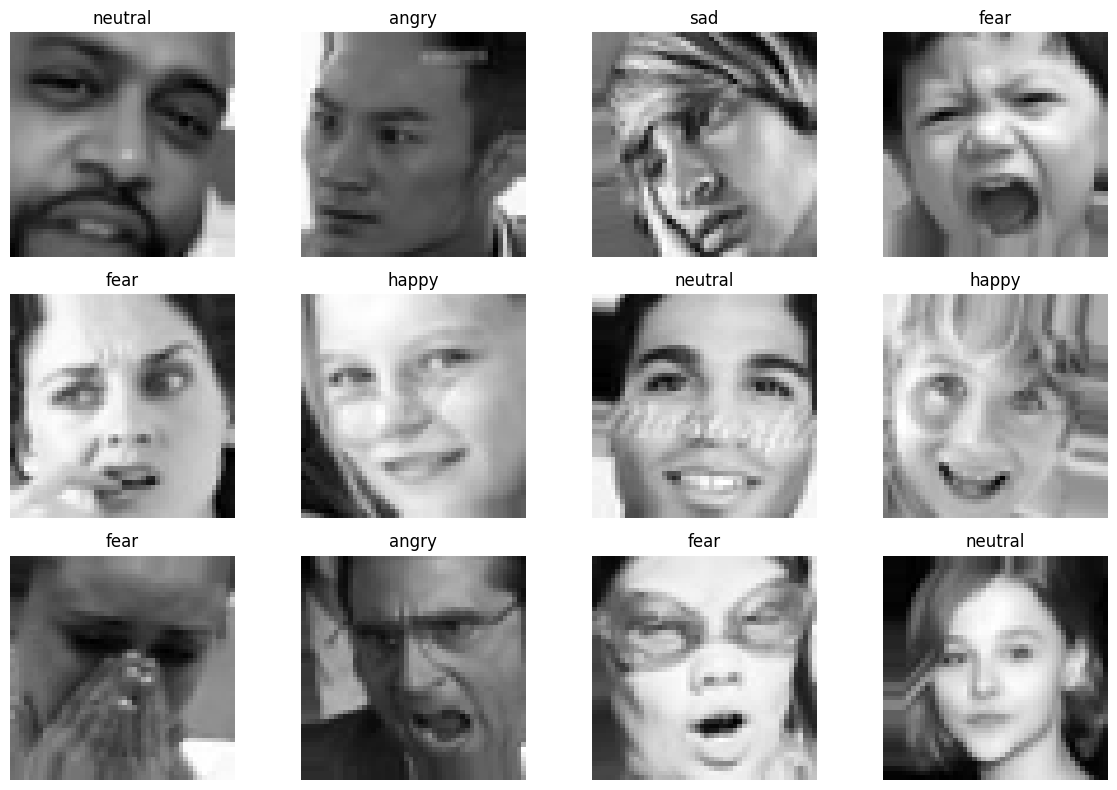

In [15]:
# Display Sample Images-->
images, labels = next(train_generator)
plt.figure(figsize=(12, 8))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(
        images[i].squeeze(),
        cmap="gray"
    )
    plt.title(
        class_names[np.argmax(labels[i])]
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [16]:
# Check Image Shape-->
print("One image shape:", images[0].shape)
print("Batch shape:", images.shape)
print("Label shape:", labels.shape)

One image shape: (48, 48, 1)
Batch shape: (64, 48, 48, 1)
Label shape: (64, 7)


In [17]:
# Check Pixel Values-->
print("Minimum pixel value:", images.min())
print("Maximum pixel value:", images.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [18]:
# Check Dataset Size-->
print("Training images:", train_generator.samples)
print("Validation images:", val_generator.samples)
print("Test images:", test_generator.samples)
print(
    "Total images:",
    train_generator.samples +
    val_generator.samples +
    test_generator.samples
)

Training images: 22968
Validation images: 5741
Test images: 7178
Total images: 35887


In [19]:
# Check Class Distribution-->
from collections import Counter
train_counts = Counter(train_generator.classes)
print("Training images per class:")
for class_name, class_index in train_generator.class_indices.items():
    print(
        class_name,
        ":",
        train_counts[class_index]
    )

Training images per class:
angry : 3196
disgust : 349
fear : 3278
happy : 5772
neutral : 3972
sad : 3864
surprise : 2537


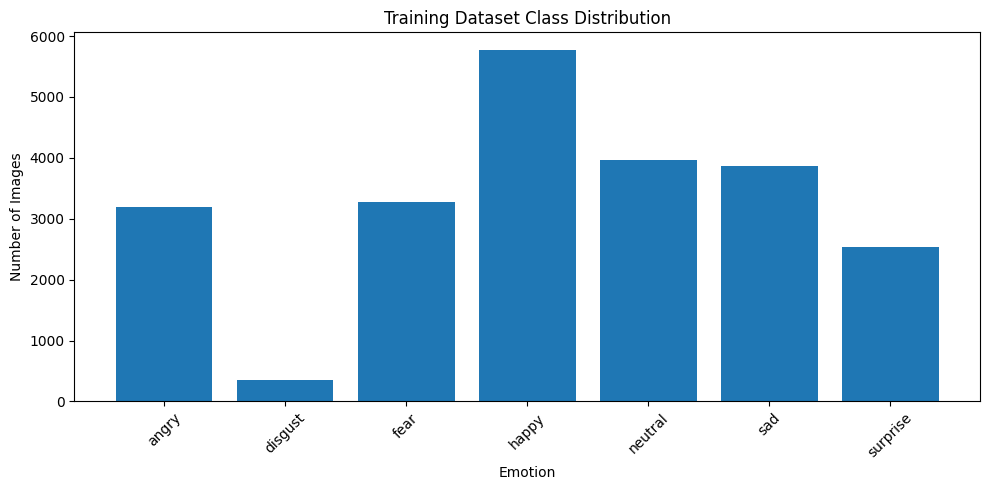

In [20]:
# Plot Class Distribution-->
class_counts = [
    train_counts[
        train_generator.class_indices[class_name]
    ]
    for class_name in class_names
]
plt.figure(figsize=(10, 5))
plt.bar(
    class_names,
    class_counts
)
plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Import CNN Layers-->
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense
)

In [23]:
# Build The CNN-->
model = Sequential([
    # Input Layer
    Input(shape=(48, 48, 1)),
    # Convolution Block 1
    Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D(
        pool_size=(2, 2)
    ),
    Dropout(0.25),
    # Convolution Block 2
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D(
        pool_size=(2, 2)
    ),
    Dropout(0.25),
    # Convolution Block 3
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    BatchNormalization(),
    MaxPooling2D(
        pool_size=(2, 2)
    ),
    Dropout(0.25),
    # Classification
    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),
    # Seven emotions
    Dense(
        7,
        activation="softmax"
    )
])

In [24]:
# Display CNN Architecture-->
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,743 (1.36 MB)

 Trainable params: 356,295 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
# Compile The CNN-->
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully!")

Model compiled successfully!


In [26]:
# Create Early Stopping-->
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
print("Early stopping configured.")

Early stopping configured.


In [27]:
# Train The CNN-->
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 40s 83ms/step - accuracy: 0.2336 - loss: 1.9065 - val_accuracy: 0.2512 - val_loss: 2.0026
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.2658 - loss: 1.7815 - val_accuracy: 0.3249 - val_loss: 1.6986
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 61ms/step - accuracy: 0.2938 - loss: 1.7326 - val_accuracy: 0.3262 - val_loss: 1.6844
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.3299 - loss: 1.6747 - val_accuracy: 0.4027 - val_loss: 1.5300
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.3518 - loss: 1.6274 - val_accuracy: 0.4313 - val_loss: 1.4752
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.3734 - loss: 1.5870 - val_accuracy: 0.4146 - val_loss: 1.5414
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.3876 - loss: 1.5642 - val_accuracy: 0.4337 - val_loss: 1.4714
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.3957 - loss: 1.5450 - 

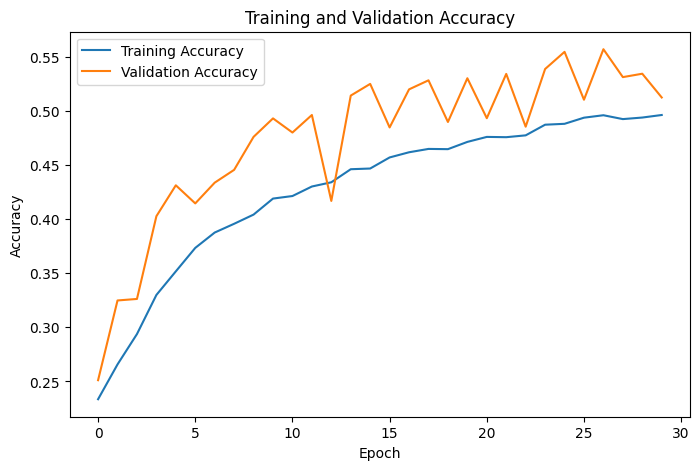

In [28]:
# Plot Training/Validation Accuracy-->
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(
    "Training and Validation Accuracy"
)
plt.legend()
plt.show()

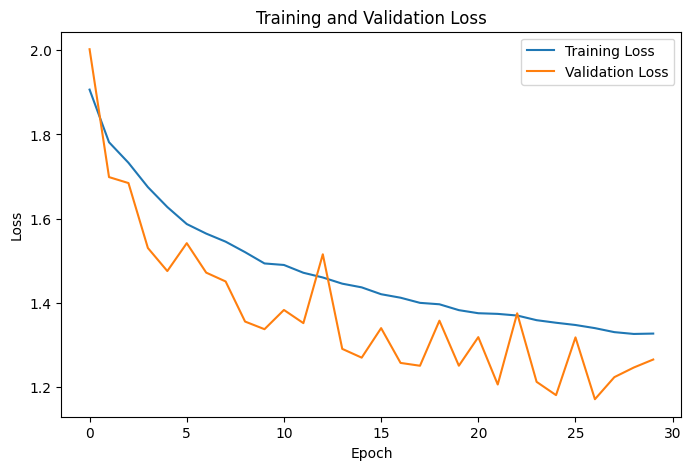

In [29]:
# Plot Training/Validation Lost-->
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Training and Validation Loss"
)
plt.legend()
plt.show()

In [30]:
# Evaluate On Test Dataset-->
test_loss, test_accuracy = model.evaluate(
    test_generator
)
print("Test Loss:", test_loss)
print(
    "Test Accuracy:",
    test_accuracy
)
print(
    "Test Accuracy (%):",
    test_accuracy * 100
)

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5605 - loss: 1.1561
Test Loss: 1.1560561656951904
Test Accuracy: 0.5604625344276428
Test Accuracy (%): 56.04625344276428


In [31]:
# Generate Predictions-->
test_generator.reset()
predictions = model.predict(
    test_generator
)
predicted_classes = np.argmax(
    predictions,
    axis=1
)
true_classes = test_generator.classes
print("Predictions generated successfully.")

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step
Predictions generated successfully.


In [32]:
# Classification Report-->
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       angry       0.49      0.40      0.44       958
     disgust       0.50      0.02      0.03       111
        fear       0.36      0.12      0.18      1024
       happy       0.80      0.81      0.81      1774
     neutral       0.45      0.68      0.55      1233
         sad       0.42      0.50      0.45      1247
    surprise       0.67      0.74      0.70       831

    accuracy                           0.56      7178
   macro avg       0.53      0.47      0.45      7178
weighted avg       0.55      0.56      0.54      7178



In [33]:
# Create The Confusion Matrix-->
cm = confusion_matrix(
    true_classes,
    predicted_classes
)

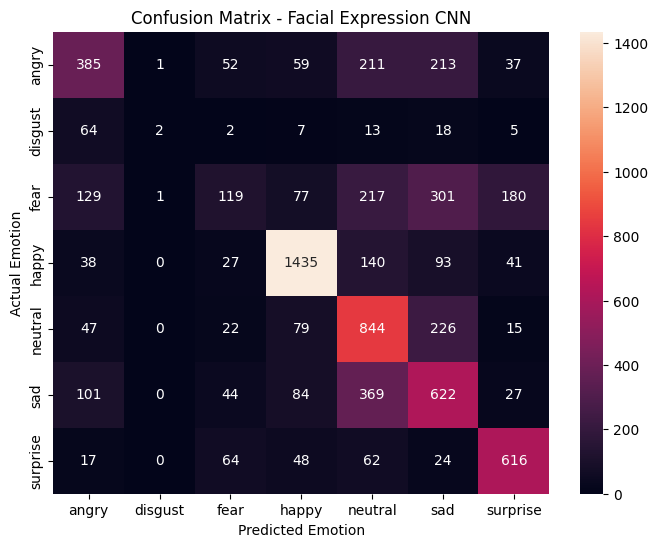

In [34]:
# Visualize The Confusion Matrix-->
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")
plt.title(
    "Confusion Matrix - Facial Expression CNN"
)
plt.show()

In [35]:
# Test A Random Individual Image-->
import random
emotion_folder = random.choice(
    class_names
)
folder_path = os.path.join(
    test_path,
    emotion_folder
)
img_file = random.choice(
    os.listdir(folder_path)
)
img_path = os.path.join(
    folder_path,
    img_file
)
print("Actual folder:", emotion_folder)
print("Image:", img_file)

Actual folder: angry
Image: PrivateTest_51610150.jpg


In [36]:
# Load It-->
from tensorflow.keras.preprocessing import image
img = image.load_img(
    img_path,
    target_size=IMG_SIZE,
    color_mode="grayscale"
)
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(
    img_array,
    axis=0
)
prediction = model.predict(
    img_array,
    verbose=0
)
predicted_index = np.argmax(
    prediction[0]
)
predicted_emotion = class_names[
    predicted_index
]
confidence = (
    prediction[0][predicted_index] * 100
)
print("Actual Emotion:", emotion_folder)
print("Predicted Emotion:", predicted_emotion)
print(
    "Confidence:",
    round(confidence, 2),
    "%"
)

Actual Emotion: angry
Predicted Emotion: happy
Confidence: 21.16 %


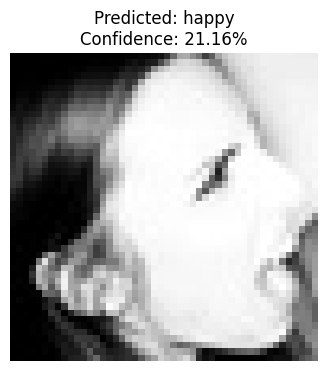

In [37]:
# Display It-->
plt.figure(figsize=(4, 4))
plt.imshow(
    img,
    cmap="gray"
)
plt.title(
    f"Predicted: {predicted_emotion}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

In [38]:
# Save The Trained Model-->
model.save(
    "/content/Facial_Expression_model.keras"
)
print(
    "Model saved successfully!"
)

Model saved successfully!


In [39]:
# Verify The Model File-->
model_path = (
    "/content/Facial_Expression_model.keras"
)
if os.path.exists(model_path):
    print("Model file exists.")
    file_size = (
        os.path.getsize(model_path)
        / (1024 * 1024)
    )
    print(
        "File size:",
        round(file_size, 2),
        "MB"
    )
else:
    print("Model file not found.")

Model file exists.
File size: 4.15 MB


In [41]:
# Test Loading From Saved Model-->
from tensorflow.keras.models import load_model
loaded_model = load_model(
    "/content/Facial_Expression_model.keras"
)
print(
    "Saved model loaded successfully!"
)

Saved model loaded successfully!


In [42]:
# Test It-->
sample_image = images[0:1]
sample_prediction = loaded_model.predict(
    sample_image,
    verbose=0
)
sample_index = np.argmax(
    sample_prediction[0]
)
print(
    "Test prediction:",
    class_names[sample_index]
)

Test prediction: sad
